# **Deep Learning Project**
# ***Predicting if a bank customer will exit the bank***

### Importing the libraries

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import wandb

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from wandb.integration.keras import WandbMetricsLogger

### Login to W&B

In [5]:
wandb.login()

True

### Importing the dataset

In [6]:
dataset = pd.read_csv("Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [7]:
#print(X)
#print(y)

## **Data preprocessing**

### Splitting the data into train & test

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [9]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography  & gender column

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [11]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Building the Nerual Network**

### Change in architecture

The initial architecture consisted of two hidden layers with 6 neurons each. While this simple structure provided stable learning behavior, it may be too limited to fully capture complex patterns in the data.

To explore whether model capacity is a limiting factor, we increase:

- The number of neurons per layer

- The number of hidden layers

By expanding the architecture, we allow the network to learn more complex feature interactions and non-linear relationships.

### Potential Risk
However, increasing model complexity also increases the risk of:

- Overfitting to the training data

- Poor generalization to validation and test sets

### Initializing the ANN

In [12]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [13]:
model.add(tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Adding the second hidden layer

In [14]:
model.add(tf.keras.layers.Dense(64, activation="relu"))

### Adding the third hidden layer

In [15]:
model.add(tf.keras.layers.Dense(32, activation="relu"))

### Adding the output layer

In [16]:
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

### Handling Class Imbalance

In [17]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights: ", class_weight_dict)

Class Weights:  {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


## **Training the ANN**


### Compiling the ANN
The model is compiled using:






In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

### Callbacks - Saving checkpoint

In [19]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Experiment Tracking with Weights & Biases (W&B)

In [20]:
RUN_NAME = "model_2_exp_2"

wandb.init(
    entity="arminfakhar1384-",
    project="bank_customers_churn",
    name=RUN_NAME,
    config={
        "model_id": 22,
        "architecture": "64-32-relu + sigmoid",
        "epochs": 100,
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "loss": "binary_crossentropy",
        "class_weight": "balanced"
    }
)

wandb_callback = WandbMetricsLogger()

### Training the ANN on the Training set

In [21]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=wandb.config.epochs,
    batch_size=wandb.config.batch_size,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, wandb_callback],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6264 - auc: 0.7046 - loss: 0.6285 - precision: 0.3212 - recall: 0.6936 - val_accuracy: 0.7069 - val_auc: 0.8196 - val_loss: 0.5571 - val_precision: 0.3852 - val_recall: 0.7812
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7502 - auc: 0.8278 - loss: 0.5085 - precision: 0.4317 - recall: 0.7499 - val_accuracy: 0.7006 - val_auc: 0.8465 - val_loss: 0.5601 - val_precision: 0.3869 - val_recall: 0.8500
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7653 - auc: 0.8456 - loss: 0.4848 - precision: 0.4503 - recall: 0.7801 - val_accuracy: 0.7244 - val_auc: 0.8530 - val_loss: 0.5280 - val_precision: 0.4079 - val_recall: 0.8375
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7723 - auc: 0.8508 - loss: 0.4851 - precision: 0.4736 - recall: 0.7730 - val_accuracy: 0.7919 - val_auc: 0.8500 - val_loss: 0.4388 - val_precision: 0.4862 - val_recall: 0.7156
Epoch 5/100
200/200 ━━━━━━━━

### Performance Visualization - Training and Validation Curves

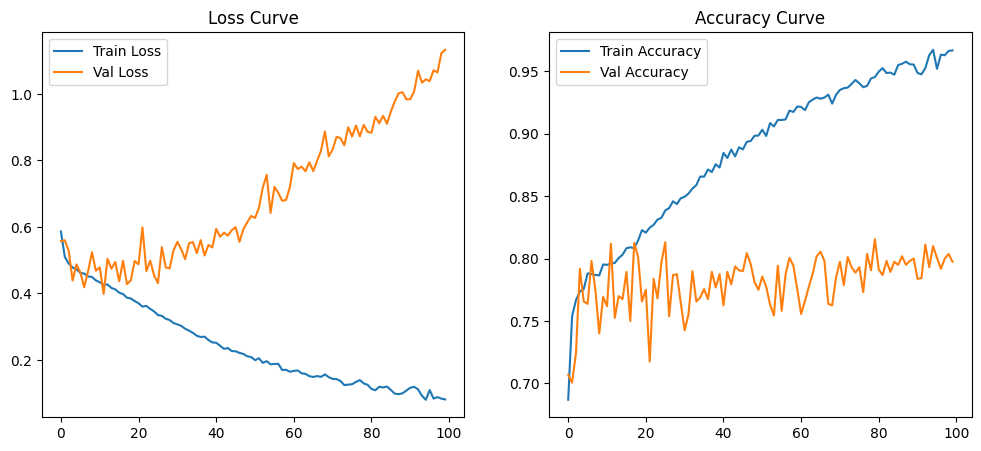

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

### Loss Curve Analysis
From the loss plot:

- Training loss continuously decreases and reaches very low values.

- Validation loss, however, initially decreases slightly but then starts increasing steadily after around ~10–15 epochs.

This divergence between training and validation loss is a classic sign of overfitting.

## **Predicting and evaluating the model**

The trained model is evaluated on the test set.

### Confusion Matrix Analysis

The confusion matrix provides detailed insight into classification errors:

*   True Positives (TP)
*   True Negatives (TN)
*   False Positives (FP)
*   False Negatives (FN)

This analysis is critical in churn prediction, where missing churned customers (FN) may be costly.

In [23]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix:
 [[1376  217]
 [ 196  211]]


**Performance metrics** such as Accuracy, Precision, Recall, F1-score, and AUC are calculated to assess generalization ability.

In [24]:
results = model.evaluate(X_test, y_test, verbose=0)
print("Test Results (loss, acc, precision, recall, auc):\n", results)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

Test Results (loss, acc, precision, recall, auc):
 [1.14236581325531, 0.7935000061988831, 0.492990642786026, 0.5184274911880493, 0.7615227103233337]

Classification Report:

              precision    recall  f1-score   support

           0     0.8753    0.8638    0.8695      1593
           1     0.4930    0.5184    0.5054       407

    accuracy                         0.7935      2000
   macro avg     0.6842    0.6911    0.6874      2000
weighted avg     0.7975    0.7935    0.7954      2000

ROC-AUC: 0.787734575870169


### Plotting ROC Curve

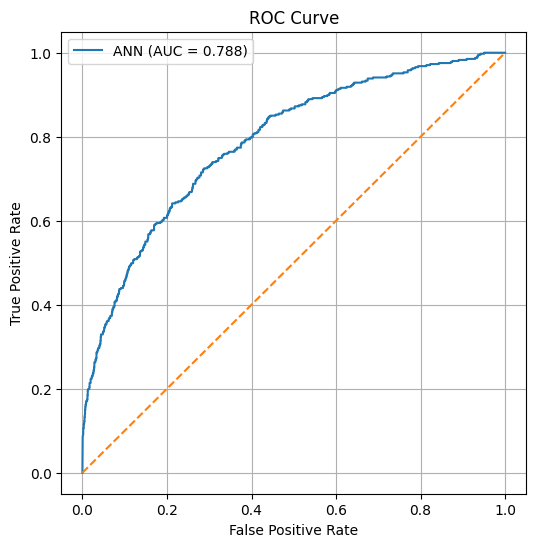

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Impact of Changing the Architecture

After increasing the model capacity by adding more layers and neurons, we observe a clear case of overfitting.

### Why is this happening?

The larger network has significantly higher capacity. It is now able to:

- Memorize training samples

- Learn noise and small fluctuations in the training data

- Fit the minority class aggressively due to class weighting

So:

- Training loss becomes very small

- Validation loss increases because the model fails to generalize

### One important observation

The training loss is much lower than before. This might look like an improvement, However, lower training loss does not mean a better model.

In fact, The validation loss is now significantly worse than in the smaller model. This tells us that the model is optimizing extremely well for the training data, but at the cost of generalization.

So although the loss function decreased on the training set, the overall model quality did not improve.

### Influence on F1-score

When a model overfits, test F1-score often does NOT improve this is because F1 depends on both precision and recall, and overfitting usually harms precision on unseen data.

### Fix
To address overfitting, we introduce regularization techniques in the next experiment:
1. Dropout
2. L2 Regularization
3. Early Stopping
